## Set Up

In [2]:
#!pip install pandas
#!pip install numpy
#!pip install matplotlib
#!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tornado.gen import multi

## Preparing Data

### Reading Data

In [3]:
# Reading in Data
df = pd.read_csv(Path.cwd() / "Data" / "Raw" / "insurance_dataset.csv",
                 dtype={"is_capped_incurred":"Int64",
                        "bi_count":"Int64",
                        "ad_count":"Int64",
                        "pd_count":"Int64",
                        "th_count":"Int64",
                        "ws_count":"Int64",
                        "vehicle_age":"Int64"})

# Converting dates and times
df["start_date"] = pd.to_datetime(df["start_date"], format = "mixed")
df["vehicle_purchase_date"] = pd.to_datetime(df["vehicle_purchase_date"], format = "mixed")
df["licence_test_date"] = pd.to_datetime(df["licence_test_date"], format = "mixed")

### Replacing Values

In [4]:
## Replacing Values
#Cleaning up the name of business providers
df["business_provider"] = df["business_provider"].str.replace({" ":"",
                                                               "+":"and",
                                                               "DefaultDefault":"Default",
                                                               "DefaultCampaign":"Default"})


#Replacing age 118 with NaN
df["d1_age"] = df["d1_age"].where(df["d1_age"] != 118)

df["d1_residency_years"] = df["d1_residency_years"].where(df["d1_residency_years"] != 118)

#Replacing NA with 0
df["incurred"] = df["incurred"].fillna(0)
df["capped_incurred"] = df["capped_incurred"].fillna(0)
df["bi_incurred"] = df["bi_incurred"].fillna(0)
df["ad_incurred"] = df["ad_incurred"].fillna(0)
df["pd_incurred"] = df["pd_incurred"].fillna(0)
df["th_incurred"] = df["th_incurred"].fillna(0)
df["ws_incurred"] = df["ws_incurred"].fillna(0)


#Replacing negatives values with NaN
df["vehicle_age"] = df["vehicle_age"].where(df["vehicle_age"] >= 0)

df["ad_incurred"] = df["ad_incurred"].where(df["ad_incurred"] >= 0)

df["th_incurred"] = df["th_incurred"].where(df["th_incurred"] >= 0)

df["incurred"] = df["incurred"].where(df["incurred"] >= 0)

df["capped_incurred"] = df["capped_incurred"].where(df["capped_incurred"] >= 0)


## Changing Casing
df["vehicle_make"] = df["vehicle_make"].str.title()

df["transmission"] = df["transmission"].str.title()

### Checking Duplicates

In [5]:
# Checking for duplicate rows
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

print(f"{df.duplicated().sum()} rows are duplicated")

print(f"{df["id"].duplicated().sum()} ID values are duplicated")


Dataset has 100000 rows and 40 columns
0 rows are duplicated
0 ID values are duplicated


### Checking Values

In [17]:
# Checking column values
#df.groupby("capped_incurred").groups.keys()

#### Looking at the values in each column, below are issues that should be addressed:

*Data Types*
- is_capped_incurred is float
- bi_count is float
- ad_count is float
- pd_count is float
- th_count is float
- ws_count is float
- vehicle_age is float

*Numeric Values*
- ad_incurred has negative values
- th_incurred has negative values
- incurred has negative values
- capped_incurred has negative values
- d1_age contains "118" values.
- d1_residency_years contains "118" values
- vehicle_value has a range of values, including single digits (not decided)
- vehicle_age contains negative values

*Character Values*
- business_provider has multiple formats for values (may be more work)
- vehicle_make is all capitalised
- transmission is all capitalised

### Profiling Missing Data

In [6]:
# Profiling missing values
missing_values = (
    pd.DataFrame(df.isna()
                 .sum())
    .reset_index()
    .rename(columns={"index":"Column",
                     0:"Values Missing"})
    .sort_values("Values Missing", ascending=False)
)

In [207]:
# Exporting Missing Values Report
#missing_values.to_csv(Path.cwd() / "Reports" / "missing_values.csv", index=False)

## High-Level Analysis

### Number of Policies Written

In [60]:
# Creating a Year column for aggregation
df["start_year"] = df["start_date"].dt.year.astype("category")
df["start_year"] = df["start_year"].cat.reorder_categories([2018, 2019, 2020])

df.groupby("start_year").id.count().reset_index().rename(columns = {"id":"Number of Policies"})

,start_year,Number of Policies
0,2018,38539
1,2019,49808
2,2020,11653


Policies written in 2020 could be low due to Covid and fewer people driving/more people working from home

### Frequency of Claims Counts

In [7]:
# Frequency of claims count
claim_frequency = pd.DataFrame(df.groupby("claim_count")
                               .id
                               .count()
                               .reset_index()
                               .rename(columns={"claim_count":"Claims Count",
                                                "id": "Frequency"}))

claim_frequency["Percentage"] = (claim_frequency["Frequency"] / claim_frequency["Frequency"].sum()) * 100
claim_frequency
# Exporting
#claim_frequency.to_csv("Reports/claim_frequency.csv", index=False)

,Claims Count,Frequency,Percentage
0,0,92581,92.581
1,1,6937,6.937
2,2,452,0.452
3,3,27,0.027
4,4,3,0.003


### Profit

In [11]:
# Calculating the total cost per person
df["final_incurred"] = np.where(df["is_capped_incurred"].fillna(0) == 1,
                                df["capped_incurred"],
                                df["incurred"])

# Calculating Profitability
df["profit"] = df["net_earned_premium"] - df["final_incurred"]

print(f"The gross earned premiums is {round(df["net_earned_premium"].sum(), 2)}")
print(f"The total incurred charges is {round(df["final_incurred"].sum(), 2)}")
print(f"Total profit made in this period is {round(df['profit'].sum(), 2)}")

The gross earned premiums is 27237225.85
The total incurred charges is 19321999.58
Total profit made in this period is 7510960.19


### Claims Frequency

In [104]:
# Calculating Claims Frequency
claims_frequency = df["claim_count"].sum() / df["exposure"].sum()

print(f"The total number of claims is {df["claim_count"].sum()}")
print(f"The total number of vehicles vehicle-years at risk is {round(df['exposure'].sum(), 2)}")
print(f"The claims frequency is {round(claims_frequency, 2)} claims per year")

The total number of claims is 7934
The total number of vehicles vehicle-years at risk is 71959.47
The claims frequency is 0.11 claims per year


## Profiling Customer Who Made Claims

### Number of Claims by Policy Year

In [22]:
# Calculating number of claims by start_year and the number of people making claims

yearly_claims = (
    pd.merge(left = df.groupby("start_year").claim_count.sum().reset_index(),
        right = df[df["claim_count"] > 0].groupby("start_year").id.count().reset_index(),
        on = "start_year")
    .rename(columns={"start_year":"Start Year",
                     "claim_count":"Total Claims",
                     "id":"Number of Customers",})
)

yearly_claims

,Start Year,Total Claims,Number of Customers
0,2018,4065,3767
1,2019,3700,3486
2,2020,169,166


### Average Claim Value

In [14]:
# Subsetting customers that made claims
df_claimed = df[df["claim_count"] > 0]

print(f"{df_claimed.shape[0]} customers made a claim")

# Calculating the average cost per claim
df_claimed["mean_claim_value"] = df_claimed["final_incurred"] / df_claimed["claim_count"]

print(f"The average claim value is {round(df_claimed["final_incurred"].mean(), 2)}")

7419 customers made a claim
The average claim value is 3044.75


<Figure size 1600x900 with 0 Axes>

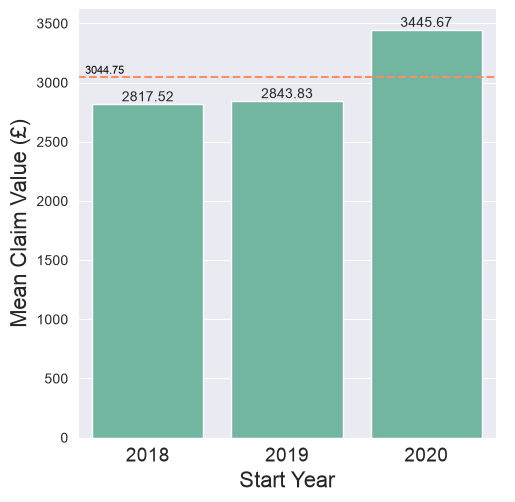

In [40]:
# Calculating the average claim cost each year
mean_claim_by_year = df_claimed.groupby("start_year").mean_claim_value.mean().reset_index()

fig = plt.figure(figsize=(16, 9))

sns.catplot(data = mean_claim_by_year,
            x = "start_year",
            y = "mean_claim_value",
            kind = "bar",
            color = sns.color_palette("Set2")[0])

plt.xlabel("Start Year", fontsize=16)
plt.ylabel("Mean Claim Value (£)", fontsize=16)
plt.xticks(fontsize=14)
plt.axhline(y=round(df_claimed["final_incurred"].mean(), 2),
            color = sns.color_palette("Set2")[1],
            linestyle="--")
plt.text(x=-0.45,
         y=round(df_claimed["final_incurred"].mean(), 2) + 30,
         s=str(round(df_claimed["final_incurred"].mean(), 2)),
         fontsize=8,
         color="black")

for i, v in enumerate(mean_claim_by_year["mean_claim_value"]):
    plt.text(i, v, str(round(v, 2)), ha = "center", va = "bottom")

plt.show()

### Type of Claims Made

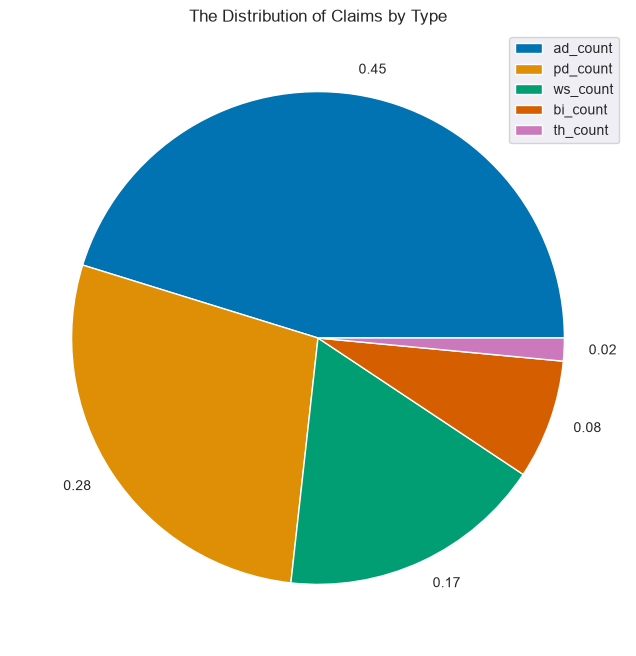

In [39]:
# Distribution of claim type
claims_by_type = (
    df_claimed.loc[:, ["bi_count", "ad_count", "pd_count", "th_count", "ws_count"]].sum()
    .reset_index()
)
claims_by_type.columns = ["Type", "Frequency"]
claims_by_type = claims_by_type.sort_values("Frequency", ascending=False)

# Calculating Proportion
claims_by_type["Proportion"] = claims_by_type["Frequency"] / claims_by_type["Frequency"].sum()

fig = plt.figure(figsize = (8, 8))

plt.pie(data = claims_by_type,
        x = "Proportion",
        labels = round(claims_by_type["Proportion"], 2),
        colors = sns.color_palette("colorblind", n_colors = 5))

plt.legend(claims_by_type["Type"])
plt.title("The Distribution of Claims by Type")

plt.show()

### Investigating No Claims Discounts

In [51]:
ncd_to_reduce = (
    df_claimed[(df_claimed["ncd"] > 0) & (df_claimed["pncd"] == "N")]
    .loc[:, ["id", "ncd", "pncd", "claim_count"]]
    .reset_index(drop=True)
)

ncd_to_reduce.head()

,id,ncd,pncd,claim_count
0,61956,6,N,1
1,35145,3,N,1
2,93633,9,N,1
3,54363,1,N,1
4,59231,2,N,1


In [54]:
offer_pncd = (
    df[(df["claim_count"] == 0) & (df["pncd"] == "N")]
    .loc[:, ["id", "ncd", "pncd", "claim_count"]]
    .reset_index(drop=True)
)

offer_pncd.head()

,id,ncd,pncd,claim_count
0,16042,0,N,0
1,65415,0,N,0
2,89268,8,N,0
3,47359,9,N,0
4,22527,0,N,0


## Investing Claim Values

In [61]:
# Calculating the average claim cost by gender
mean_claim_by_gender = df_claimed.groupby("gender").mean_claim_value.mean().reset_index()

# Calculating the average claim cost by age
mean_claim_by_age = df_claimed.groupby("d1_age").mean_claim_value.mean().reset_index()

# Calculating the average claim cost by vehicle make
mean_claim_by_make = df_claimed.groupby("vehicle_make").mean_claim_value.mean().reset_index()

# Calculating the average claim cost by vehicle use
mean_claim_by_use = df_claimed.groupby("vehicle_use").mean_claim_value.mean().reset_index()

# Calculating the average claim cost by cover
mean_claim_by_cover = df_claimed.groupby("cover").mean_claim_value.mean().reset_index()

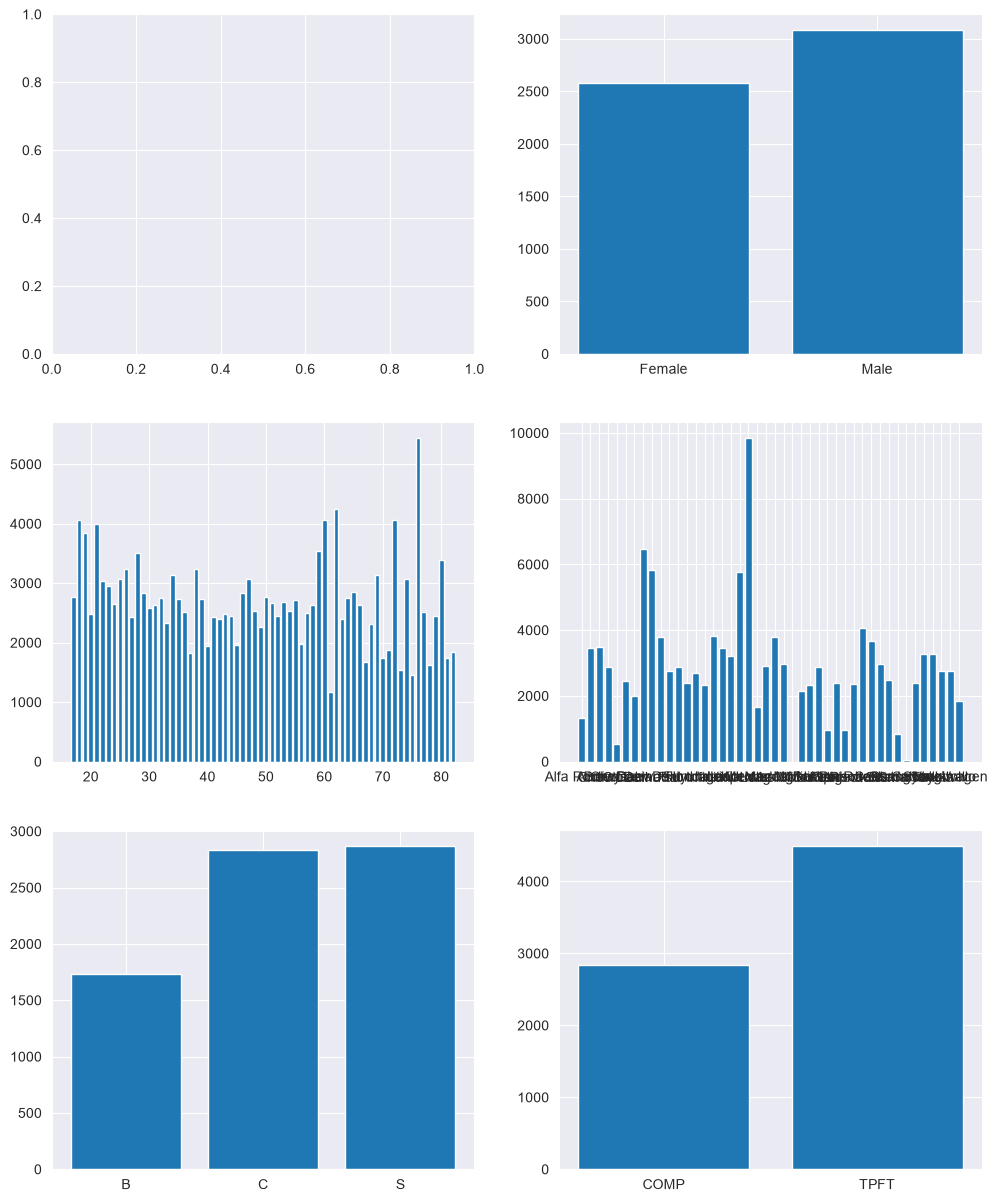

In [62]:
fig, axes = plt.subplots(nrows=3,
                   ncols=2,
                   figsize=(12,15))

axes[0, 1].bar(x = mean_claim_by_gender["gender"],
               height = mean_claim_by_gender["mean_claim_value"])

axes[1, 0].bar(x = mean_claim_by_age["d1_age"],
               height = mean_claim_by_age["mean_claim_value"])

axes[1, 1].bar(x = mean_claim_by_make["vehicle_make"],
               height = mean_claim_by_make["mean_claim_value"])

axes[2, 0].bar(x = mean_claim_by_use["vehicle_use"],
               height = mean_claim_by_use["mean_claim_value"])

axes[2, 1].bar(x = mean_claim_by_cover["cover"],
               height = mean_claim_by_cover["mean_claim_value"])

plt.show()

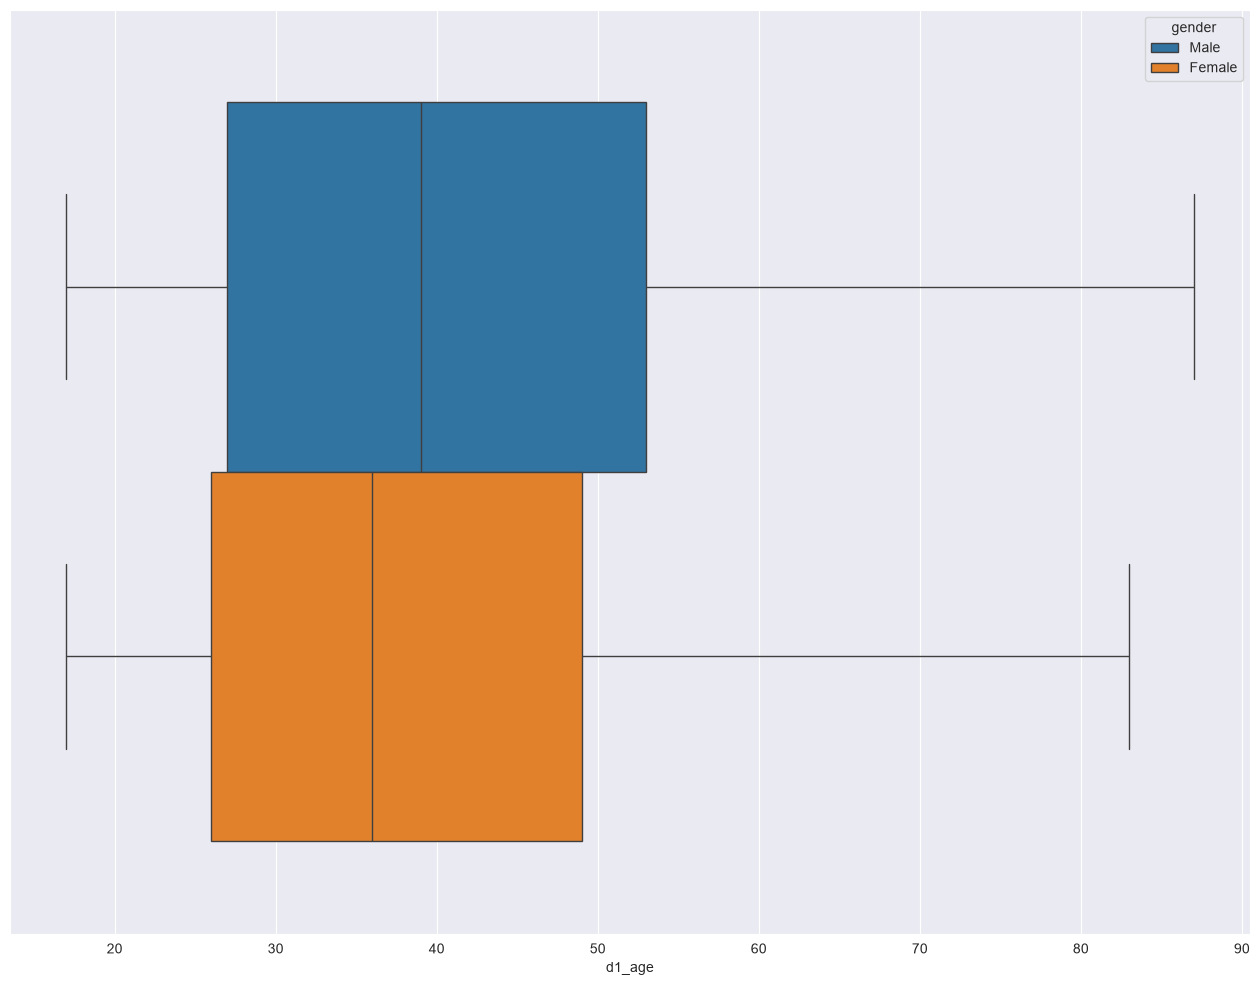

In [215]:
# Plotting the age distribution of each gender
fig = plt.figure(figsize = (16,12))

sns.boxplot(data = df[df["gender"] != "Unknown"],
            x = "d1_age",
            hue = "gender")

plt.show()

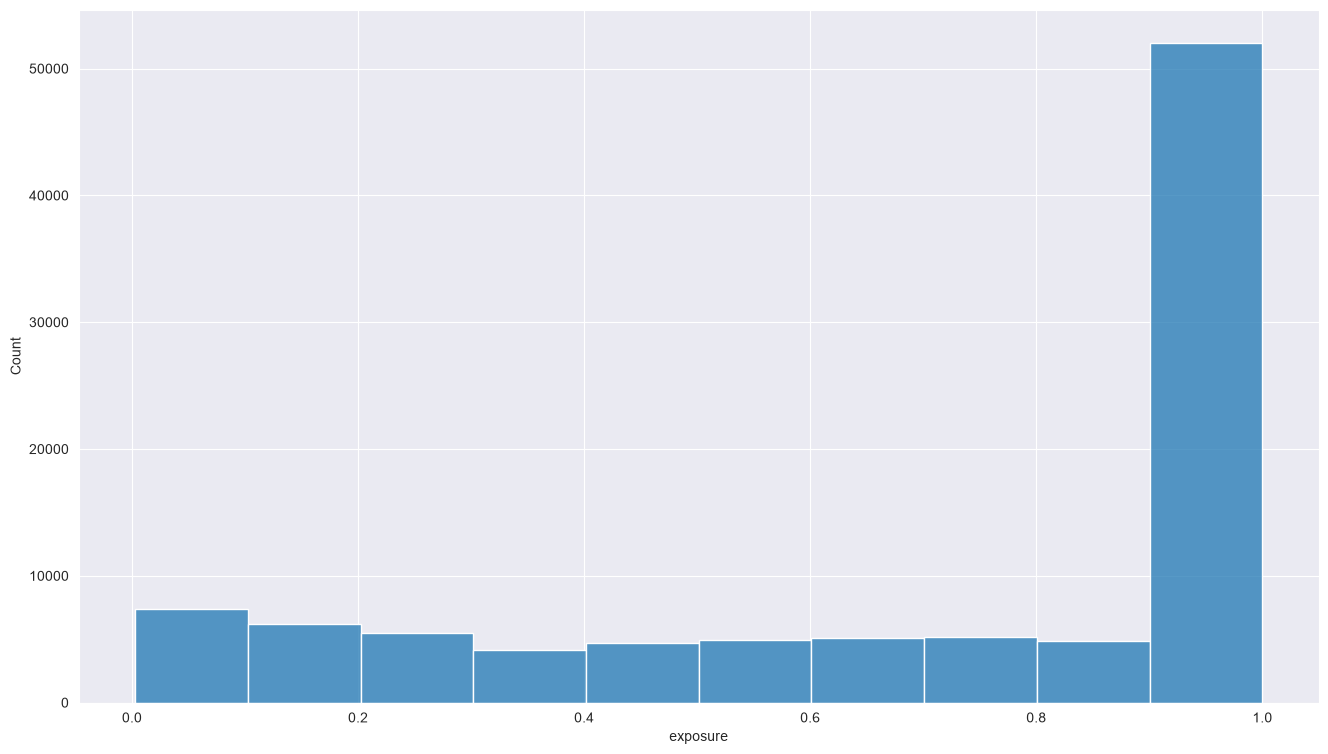

In [216]:
# Exposure distribution

fig = plt.figure(figsize = (16,9))

sns.histplot(data = df,
            x = "exposure",
             bins = 10)

plt.show()

Total profit made in this period is 7915570.27


## Profiling Customers Who Did Not Make Claims

In [226]:
# Identifying "safest" demographic.
df_no_claim = df[df["claim_count"] == 0]

df_no_claim.groupby("gender").id.count()

gender
Female     42515
Male       50064
Unknown        2
Name: id, dtype: int64